# Modul 1: Accounting — Monatsabschluss / Monthly Closing

**DE:** Simulation eines vollständigen Monatsabschlusses auf Basis realer Verkaufsdaten (Bike Sales, 2011–2016).  
**EN:** Simulation of a complete monthly closing process based on real sales data (Bike Sales, 2011–2016).

---

## 📚 Konzept: Was ist ein Monatsabschluss? / What is a Monthly Closing?

**DE:**  
Der Monatsabschluss (auch: Periodenabschluss) ist ein zentraler Prozess im Rechnungswesen. Er stellt sicher, dass alle wirtschaftlichen Vorgänge einer Periode vollständig und korrekt erfasst, bewertet und ausgewiesen werden.

**Typischer Ablauf (Working-Day-Logik):**
| Tag | Aufgabe |
|-----|---------|
| WD-3 | Rohdaten prüfen & bereinigen |
| WD-2 | Kontenabstimmung (Reconciliation) |
| WD-1 | Rechnungsabgrenzung, Plan-Ist-Vergleich, GuV |
| WD 0 | Management Review & Freigabe |
| WD+1 | Archivierung |

**EN:**  
The monthly closing ensures all transactions in a period are completely and correctly recorded. The P&L (Profit & Loss Statement) is the core output.

---

## 📋 Inhaltsverzeichnis / Table of Contents
1. [Daten laden / Load Data](#1-daten-laden)
2. [Monatliche GuV / Monthly P&L](#2-monatliche-guv) ← *Kern-Abschluss*
3. [Rechnungsabgrenzung / Accruals](#3-rechnungsabgrenzung) ← *ARAP & PRAP*
4. [Kontenabstimmung / Reconciliation](#4-kontenabstimmung) ← *Kontrolle*
5. [Jahresabschluss / Annual Closing](#5-jahresabschluss)
6. [Abweichungskommentar / Variance Commentary](#6-abweichungskommentar)
7. [Export nach Excel / Export to Excel](#7-export)


## 0. Setup & Imports

In [1]:
# =============================================================
# IMPORTS
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Plot-Stil / Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
    'font.size':        10
})

print('✓ Libraries loaded / Bibliotheken geladen')

✓ Libraries loaded / Bibliotheken geladen


## 1. Daten laden / Load Data <a id='1-daten-laden'></a>

**DE:** Wir laden die bereinigten Daten aus Modul 0. Diese enthalten:
- `revenue` = tatsächlicher Umsatz pro Transaktion (Ist-Wert)
- `cost` = tatsächliche Kosten pro Transaktion (COGS)
- `profit` = revenue − cost (bereits in den Rohdaten berechnet)
- `revenue_plan` = geplanter Umsatz (Planwert / Budget)
- `fiscal_year`, `quarter`, `date` = Zeitinformationen

**EN:** We load cleaned data from Module 0. Key columns:
- `revenue` = actual revenue per transaction
- `cost` = actual cost per transaction (COGS)  
- `profit` = revenue − cost (pre-calculated in raw data)
- `revenue_plan` = planned/budgeted revenue


In [2]:
# ------------------------------------------------------------------
# DE: Vorbereitete Daten aus Modul 0 laden
# EN: Load prepared data from Module 0
# ------------------------------------------------------------------

df = pd.read_csv('../data/processed/bike_sales_clean.csv')
df['date']       = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

print(f'Datensatz geladen / Dataset loaded: {len(df):,} Zeilen/rows')
print(f'Zeitraum / Period: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Länder / Countries: {sorted(df["country"].unique())}')
print()
print('Relevante Spalten / Relevant columns:')
for col in ['revenue', 'cost', 'profit', 'revenue_plan', 'fiscal_year', 'quarter']:
    if col in df.columns:
        print(f'  {col:15s}: {df[col].dtype}  |  Beispiel: {df[col].iloc[0]}')

Datensatz geladen / Dataset loaded: 113,036 Zeilen/rows
Zeitraum / Period: 2011-01-01 → 2016-07-31
Länder / Countries: ['Australia', 'Canada', 'France', 'Germany', 'United Kingdom', 'United States']

Relevante Spalten / Relevant columns:
  revenue        : int64  |  Beispiel: 950
  cost           : int64  |  Beispiel: 360
  profit         : int64  |  Beispiel: 590
  revenue_plan   : float64  |  Beispiel: 921.0
  fiscal_year    : int64  |  Beispiel: 2013
  quarter        : str  |  Beispiel: Q4


## 2. Monatliche GuV / Monthly P&L (Profit & Loss) <a id='2-monatliche-guv'></a>

### 📖 Konzept / Concept

**DE: Gewinn- und Verlustrechnung (GuV)**  
Die GuV zeigt, welche Erträge und Aufwendungen in einer Periode angefallen sind.

```
Struktur / Structure:
┌─────────────────────────────────────────────────┐
│  (+) Umsatzerlöse (Revenue)                      │
│  (−) Umsatzkosten / COGS (Cost of Goods Sold)   │
│  ─────────────────────────────────────────────  │
│  (=) Bruttoergebnis (Gross Profit)               │
│      Bruttomarge % = Bruttoergebnis / Umsatz     │
└─────────────────────────────────────────────────┘
```

**Wichtige Kennzahlen / Key Metrics:**
- **Bruttomarge (Gross Margin %)** = Wie viel % des Umsatzes als Gewinn bleibt, bevor Overheads abgezogen werden. Ziel: stabil & positiv.
- **Abweichung (Variance)** = Ist − Plan. Positiv = besser als Plan. 
- **RAG-Status**: 🟢 ≥ +3% | 🟡 −3% bis +3% | 🔴 < −3%

**EN:** The P&L statement shows revenues and expenses for a period. Gross Profit = Revenue − COGS. Gross Margin = GP / Revenue.

### 🔢 Formeln / Formulas
| Kennzahl | Formel | Spaltenname |
|----------|--------|-------------|
| Bruttoergebnis | `revenue - cost` | `Ergebnis_Ist` |
| Bruttomarge % | `Ergebnis / Umsatz * 100` | `Bruttomarge_Ist_pct` |
| Abw. absolut | `Ist - Plan` | `Umsatz_Abw_abs` |
| Abw. % | `(Ist - Plan) / Plan * 100` | `Umsatz_Abw_pct` |


In [3]:
# ------------------------------------------------------------------
# DE: Schritt 1 – Monatliche GuV aggregieren
#     Wir summieren alle Transaktionen pro Monat (groupby)
# EN: Step 1 – Aggregate monthly P&L
#     Sum all transactions per month using groupby
# ------------------------------------------------------------------

monthly = df.groupby(['fiscal_year', 'quarter', 'year_month']).agg(
    Umsatz_Ist      = ('revenue',       'sum'),   # Summe aller revenue-Transaktionen
    Kosten_Ist      = ('cost',          'sum'),   # Summe aller cost-Transaktionen
    Ergebnis_Ist    = ('profit',        'sum'),   # Summe aller profit-Transaktionen
    Umsatz_Plan     = ('revenue_plan',  'sum'),   # Summe der Planwerte
    Kosten_Plan     = ('cost_plan',     'sum'),   # Summe der Plan-Kosten
    Ergebnis_Plan   = ('profit_plan',   'sum'),   # Summe des Plan-Ergebnisses
    Bestellmenge    = ('order_quantity','sum')    # Anzahl Einheiten
).reset_index()

# ------------------------------------------------------------------
# DE: Schritt 2 – Kennzahlen berechnen
#     Bruttomarge = Ergebnis / Umsatz * 100
# EN: Step 2 – Calculate KPIs
# ------------------------------------------------------------------
monthly['Bruttomarge_Ist_pct']  = (monthly['Ergebnis_Ist']  / monthly['Umsatz_Ist']  * 100).round(2)
monthly['Bruttomarge_Plan_pct'] = (monthly['Ergebnis_Plan'] / monthly['Umsatz_Plan'] * 100).round(2)

# ------------------------------------------------------------------
# DE: Schritt 3 – Abweichungen berechnen (Ist vs. Plan)
#     Abw.abs = Ist − Plan    → positiv = besser als geplant
#     Abw.%   = Abw.abs / Plan × 100
# EN: Step 3 – Calculate variances (Actual vs. Budget)
# ------------------------------------------------------------------
monthly['Umsatz_Abw_abs']   = monthly['Umsatz_Ist']   - monthly['Umsatz_Plan']
monthly['Umsatz_Abw_pct']   = (monthly['Umsatz_Abw_abs'] / monthly['Umsatz_Plan'] * 100).round(2)
monthly['Ergebnis_Abw_abs'] = monthly['Ergebnis_Ist'] - monthly['Ergebnis_Plan']
monthly['Ergebnis_Abw_pct'] = (monthly['Ergebnis_Abw_abs'] / monthly['Ergebnis_Plan'] * 100).round(2)

# ------------------------------------------------------------------
# DE: Schritt 4 – RAG-Status (Rot/Amber/Grün / Red/Amber/Green)
#     Schwellenwerte: ±3% = Industrie-Standard für Monatsabschluss
#     🟢 ≥ +3%  |  🟡 zwischen -3% und +3%  |  🔴 < -3%
# EN: Step 4 – RAG status (±3% threshold = industry standard)
# ------------------------------------------------------------------
def rag_status(pct):
    if pct >= 3:    return '🟢 Grün/Green'
    elif pct >= -3: return '🟡 Amber'
    else:           return '🔴 Rot/Red'

monthly['RAG_Umsatz']   = monthly['Umsatz_Abw_pct'].apply(rag_status)
monthly['RAG_Ergebnis'] = monthly['Ergebnis_Abw_pct'].apply(rag_status)
monthly['year_month_str'] = monthly['year_month'].astype(str)

print(f'✓ monthly DataFrame erstellt / created: {len(monthly)} Zeilen/rows')
print(f'  Spalten / Columns: {list(monthly.columns)}')

✓ monthly DataFrame erstellt / created: 62 Zeilen/rows
  Spalten / Columns: ['fiscal_year', 'quarter', 'year_month', 'Umsatz_Ist', 'Kosten_Ist', 'Ergebnis_Ist', 'Umsatz_Plan', 'Kosten_Plan', 'Ergebnis_Plan', 'Bestellmenge', 'Bruttomarge_Ist_pct', 'Bruttomarge_Plan_pct', 'Umsatz_Abw_abs', 'Umsatz_Abw_pct', 'Ergebnis_Abw_abs', 'Ergebnis_Abw_pct', 'RAG_Umsatz', 'RAG_Ergebnis', 'year_month_str']


In [4]:
# ------------------------------------------------------------------
# DE: GuV-Vorschau 2015 – typische Ausgabe im Abschluss
# EN: P&L preview 2015 – typical closing output
# ------------------------------------------------------------------

cols = ['year_month_str','Umsatz_Ist','Kosten_Ist','Ergebnis_Ist',
        'Bruttomarge_Ist_pct','Umsatz_Abw_pct','RAG_Umsatz']
display_df = monthly[monthly['fiscal_year']==2015][cols].copy()
display_df.columns = ['Periode','Umsatz (Ist)','Kosten (Ist)','Ergebnis (Ist)',
                      'Marge %','Umsatz Abw. %','RAG']

print('=' * 78)
print('MONATLICHE GuV 2015 / MONTHLY P&L 2015 — RetailCo')
print('=' * 78)
print(f'{"Periode":<10} {"Umsatz (Ist)":>14} {"Kosten (Ist)":>14} '
      f'{"GP (Ist)":>14} {"Marge%":>8} {"Abw%":>8}  RAG')
print('-' * 78)
for _, r in display_df.iterrows():
    print(f'{r["Periode"]:<10} {r["Umsatz (Ist)"]:>14,.0f} {r["Kosten (Ist)"]:>14,.0f} '
          f'{r["Ergebnis (Ist)"]:>14,.0f} {r["Marge %"]:>7.1f}% {r["Umsatz Abw. %"]:>7.1f}%  {r["RAG"]}')
print('-' * 78)
tot = monthly[monthly['fiscal_year']==2015]
print(f'{"GESAMT":<10} {tot["Umsatz_Ist"].sum():>14,.0f} {tot["Kosten_Ist"].sum():>14,.0f} '
      f'{tot["Ergebnis_Ist"].sum():>14,.0f} '
      f'{tot["Ergebnis_Ist"].sum()/tot["Umsatz_Ist"].sum()*100:>7.1f}%')
print('=' * 78)

MONATLICHE GuV 2015 / MONTHLY P&L 2015 — RetailCo
Periode      Umsatz (Ist)   Kosten (Ist)       GP (Ist)   Marge%     Abw%  RAG
------------------------------------------------------------------------------
2015-01           666,938        447,744        219,194    32.9%     0.2%  🟡 Amber
2015-02           679,246        458,635        220,611    32.5%     0.9%  🟡 Amber
2015-03           714,008        477,922        236,086    33.1%     0.3%  🟡 Amber
2015-04           734,608        497,020        237,588    32.3%     0.8%  🟡 Amber
2015-05           895,043        597,749        297,294    33.2%    -0.7%  🟡 Amber
2015-06           786,480        527,616        258,864    32.9%    -0.0%  🟡 Amber
2015-07         1,728,398      1,118,446        609,952    35.3%     0.4%  🟡 Amber
2015-08         2,140,581      1,264,046        876,535    41.0%     0.0%  🟡 Amber
2015-09         2,465,172      1,478,781        986,391    40.0%     0.2%  🟡 Amber
2015-10         2,529,084      1,528,465     

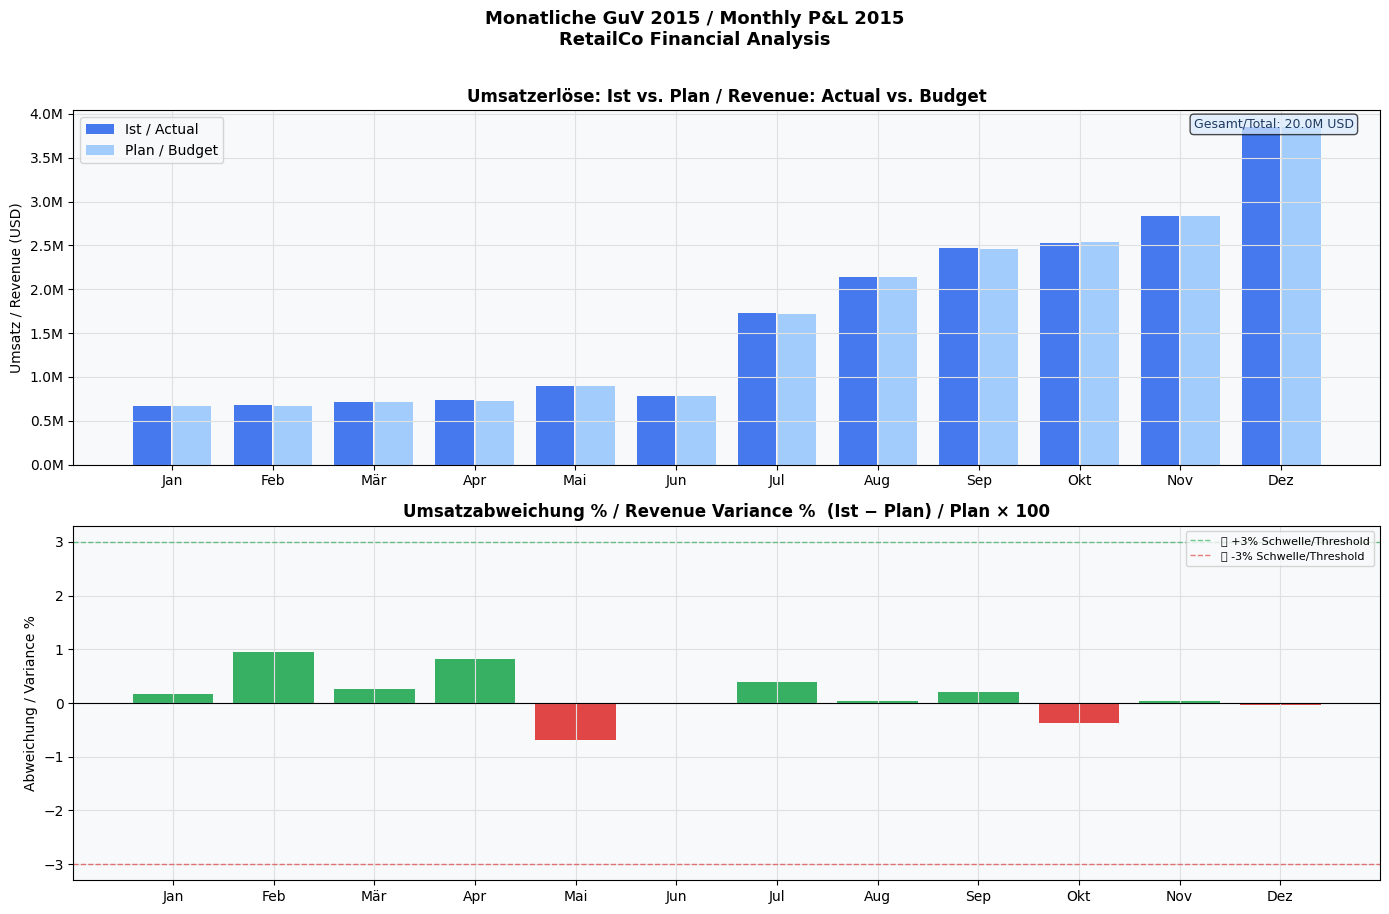

✓ Chart gespeichert / saved: chart_monthly_pl_2015.png


In [5]:
# ------------------------------------------------------------------
# DE: Visualisierung Ist vs. Plan (2015)
# EN: Revenue Actual vs. Plan visualization (2015)
# ------------------------------------------------------------------

m2015 = monthly[monthly['fiscal_year'] == 2015].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Monatliche GuV 2015 / Monthly P&L 2015\nRetailCo Financial Analysis',
             fontsize=13, fontweight='bold', y=1.01)

months_short = ['Jan','Feb','Mär','Apr','Mai','Jun',
                'Jul','Aug','Sep','Okt','Nov','Dez']
x = range(len(m2015))

# Chart 1: Umsatz Ist vs. Plan
ax1 = axes[0]
ax1.bar([i - 0.2 for i in x], m2015['Umsatz_Ist'],   width=0.38, label='Ist / Actual',  color='#2563eb', alpha=0.85)
ax1.bar([i + 0.2 for i in x], m2015['Umsatz_Plan'],  width=0.38, label='Plan / Budget', color='#93c5fd', alpha=0.85)
ax1.set_title('Umsatzerlöse: Ist vs. Plan / Revenue: Actual vs. Budget', fontweight='bold')
ax1.set_xticks(list(x))
ax1.set_xticklabels(months_short[:len(m2015)])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax1.set_ylabel('Umsatz / Revenue (USD)')
ax1.legend()
# Annotation: Gesamtumsatz / Total revenue
total_rev = m2015['Umsatz_Ist'].sum()
ax1.annotate(f'Gesamt/Total: {total_rev/1e6:.1f}M USD',
             xy=(0.98, 0.95), xycoords='axes fraction', ha='right',
             fontsize=9, color='#1e3a5f',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#dbeafe', alpha=0.7))

# Chart 2: Abweichung %
ax2 = axes[1]
colors = ['#16a34a' if v >= 0 else '#dc2626' for v in m2015['Umsatz_Abw_pct']]
ax2.bar(list(x), m2015['Umsatz_Abw_pct'], color=colors, alpha=0.85)
ax2.axhline(0,  color='black',   linewidth=0.8)
ax2.axhline(3,  color='#16a34a', linewidth=1, linestyle='--', alpha=0.6, label='🟢 +3% Schwelle/Threshold')
ax2.axhline(-3, color='#dc2626', linewidth=1, linestyle='--', alpha=0.6, label='🔴 -3% Schwelle/Threshold')
ax2.set_title('Umsatzabweichung % / Revenue Variance %  (Ist − Plan) / Plan × 100', fontweight='bold')
ax2.set_xticks(list(x))
ax2.set_xticklabels(months_short[:len(m2015)])
ax2.set_ylabel('Abweichung / Variance %')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/chart_monthly_pl_2015.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart gespeichert / saved: chart_monthly_pl_2015.png')

## 3. Rechnungsabgrenzung / Accruals <a id='3-rechnungsabgrenzung'></a>

### 📖 Konzept / Concept

**DE: Was ist Rechnungsabgrenzung?**

Das Periodenabgrenzungsprinzip (§ 250 HGB / IAS 1.27) verlangt, dass Erträge und Aufwendungen in der Periode ausgewiesen werden, in der sie **wirtschaftlich entstehen** – unabhängig vom Zahlungszeitpunkt.

```
Zwei Typen / Two types:

┌─ ARAP – Aktive Rechnungsabgrenzung ──────────────────────────────┐
│  = Prepaid Revenue / Deferred Revenue                             │
│  Umsatz wurde vereinnahmt, aber Leistung noch nicht erbracht.    │
│  → Umsatz wird auf nächste Periode verschoben.                   │
│  Buchung: Soll ARAP (Aktiva/Asset) | Haben Umsatzerlöse          │
│  Formel: ARAP = Umsatz_Ist × 5%                                  │
└──────────────────────────────────────────────────────────────────┘

┌─ PRAP – Passive Rechnungsabgrenzung ─────────────────────────────┐
│  = Prepaid Expense / Deferred Cost                                │
│  Zahlung erfolgt, aber Aufwand betrifft nächste Periode.          │
│  → Kosten werden auf nächste Periode verschoben.                  │
│  Buchung: Soll Aufwand | Haben PRAP (Passiva/Liability)           │
│  Formel: PRAP = Kosten_Ist × 3%                                  │
└──────────────────────────────────────────────────────────────────┘
```

**Auswirkung auf Ergebnis / Impact on result:**
```
Ergebnis_bereinigt = Ergebnis_Ist − ARAP + PRAP
                                     ↑          ↑
                               Ergebnis sinkt  Aufwand dieser
                               (Umsatz wird    Periode sinkt
                               verschoben)     (Kosten werden
                                               verschoben)
```

**EN:** Accruals ensure matching of revenues and expenses to the correct period.
- **ARAP (Prepaid Revenue)**: 5% of revenue deferred to next period → reduces current profit
- **PRAP (Deferred Cost)**: 3% of costs belong to next period → reduces current expenses

### Annahmen (in der Realität: aus Buchführungssystem)
| Parameter | Wert | Herkunft |
|-----------|------|---------|
| ARAP_RATE | 5% | Simulation; in der Praxis: offene Rechnungen aus ERP |
| PRAP_RATE | 3% | Simulation; in der Praxis: Abgrenzungsliste aus ERP |


In [6]:
# ------------------------------------------------------------------
# DE: Rechnungsabgrenzungsposten berechnen
#
#     ARAP (Aktiv / Prepaid Revenue):
#       - 5% des monatlichen Umsatzes wurde noch nicht geleistet
#       - Dieser Teil gehört zur nächsten Periode
#       - Buchung: Soll ARAP | Haben Umsatzerlöse
#       - Effekt: Ergebnis dieser Periode sinkt um ARAP
#
#     PRAP (Passiv / Deferred Cost):
#       - 3% der Kosten betreffen die nächste Periode
#       - Diese Kosten dürfen nicht in dieser Periode gebucht werden
#       - Buchung: Soll Aufwand | Haben PRAP
#       - Effekt: Aufwand dieser Periode sinkt um PRAP → Ergebnis steigt
#
# EN: Calculate accruals (prepaid/deferred items)
# ------------------------------------------------------------------

ARAP_RATE = 0.05  # 5% Umsatz → wird auf nächste Periode verschoben
PRAP_RATE = 0.03  # 3% Kosten → betreffen nächste Periode

# ARAP: 5% des Umsatzes = abgegrenzter Ertrag (noch nicht verdient)
monthly['ARAP_Aktiv']  = (monthly['Umsatz_Ist'] * ARAP_RATE).round(0)

# PRAP: 3% der Kosten = antizipierter Aufwand (noch nicht fällig)
monthly['PRAP_Passiv'] = (monthly['Kosten_Ist'] * PRAP_RATE).round(0)

# Bereinigtes Ergebnis:
#   = Ergebnis_Ist                   (Umsatz − COGS, ungekürzt)
#   − ARAP_Aktiv                     (Umsatzanteil, der nicht dieser Periode gehört)
#   + PRAP_Passiv                    (Kostenanteil, der nicht dieser Periode belastet wird)
monthly['Ergebnis_bereinigt'] = (
    monthly['Ergebnis_Ist']
    - monthly['ARAP_Aktiv']
    + monthly['PRAP_Passiv']
).round(0)

# ------------------------------------------------------------------
# Ausgabe / Output
# ------------------------------------------------------------------
accrual_cols = ['year_month_str','Umsatz_Ist','Ergebnis_Ist',
                'ARAP_Aktiv','PRAP_Passiv','Ergebnis_bereinigt']
acc2015 = monthly[monthly['fiscal_year']==2015][accrual_cols].copy()

print(f'Annahmen / Assumptions: ARAP = {ARAP_RATE*100:.0f}% × Umsatz  |  PRAP = {PRAP_RATE*100:.0f}% × Kosten')
print()
print(f'{"Periode":<10} {"Umsatz":>12} {"Erg.Ist":>12} {"ARAP(−)":>10} '
      f'{"PRAP(+)":>10} {"Erg.bereinigt":>15}')
print('-' * 73)
for _, r in acc2015.iterrows():
    delta = r['Ergebnis_bereinigt'] - r['Ergebnis_Ist']
    print(f'{r["year_month_str"]:<10} {r["Umsatz_Ist"]:>12,.0f} '
          f'{r["Ergebnis_Ist"]:>12,.0f} {r["ARAP_Aktiv"]:>10,.0f} '
          f'{r["PRAP_Passiv"]:>10,.0f} {r["Ergebnis_bereinigt"]:>15,.0f} '
          f'  (Δ {delta:+,.0f})')
print()
print('Erläuterung / Explanation:')
print('  ARAP (−): Umsatzanteil der nächsten Periode → Ergebnis sinkt')
print('  PRAP (+): Kostenanteil der nächsten Periode → Ergebnis steigt')
print('  Δ = Bereinigtes Ergebnis − Rohes Ergebnis')

Annahmen / Assumptions: ARAP = 5% × Umsatz  |  PRAP = 3% × Kosten

Periode          Umsatz      Erg.Ist    ARAP(−)    PRAP(+)   Erg.bereinigt
-------------------------------------------------------------------------
2015-01         666,938      219,194     33,347     13,432         199,279   (Δ -19,915)
2015-02         679,246      220,611     33,962     13,759         200,408   (Δ -20,203)
2015-03         714,008      236,086     35,700     14,338         214,724   (Δ -21,362)
2015-04         734,608      237,588     36,730     14,911         215,769   (Δ -21,819)
2015-05         895,043      297,294     44,752     17,932         270,474   (Δ -26,820)
2015-06         786,480      258,864     39,324     15,828         235,368   (Δ -23,496)
2015-07       1,728,398      609,952     86,420     33,553         557,085   (Δ -52,867)
2015-08       2,140,581      876,535    107,029     37,921         807,427   (Δ -69,108)
2015-09       2,465,172      986,391    123,259     44,363         907,4

## 4. Kontenabstimmung / Reconciliation <a id='4-kontenabstimmung'></a>

### 📖 Konzept / Concept

**DE: Was ist eine Kontenabstimmung?**

Die Kontenabstimmung (Account Reconciliation) ist eine der wichtigsten Kontrollen im Abschluss. Sie prüft:

> **Summe aller Einzeltransaktionen = Aggregierter Monatswert**

Falls eine Differenz besteht, gibt es einen Fehler in der Aggregation, Doppelbuchungen oder fehlende Datensätze.

```
Kontrolle / Control:
  Transaktionsebene:  Σ df['revenue']          (alle Einzelbuchungen)
  Aggregierte Ebene:  Σ monthly['Umsatz_Ist']  (monatlich summiert)
  ─────────────────────────────────────────────────────────────────
  Differenz:          = 0 ✅  oder  ≠ 0 ❌ → Fehlersuche nötig
```

**EN:** Reconciliation verifies that the sum of all individual transactions equals the aggregated monthly totals. Any difference ≠ 0 requires investigation.


In [7]:
# ------------------------------------------------------------------
# DE: Kontenabstimmung – Transaktionsebene vs. Aggregierte Ebene
#
#     Ziel: Σ(Transaktionen) == Σ(Aggregierte Monatswerte)
#     Falls Differenz ≠ 0: Datenfehler, Doppelbuchung oder
#                          unterschiedliche Aggregationslogik
#
# EN: Reconciliation – Transaction level vs. Aggregated level
# ------------------------------------------------------------------

# Transaktionsebene: direkt aus df (Rohdaten)
tx_revenue_2015 = df[df['fiscal_year'] == 2015]['revenue'].sum()
tx_cost_2015    = df[df['fiscal_year'] == 2015]['cost'].sum()
tx_profit_2015  = df[df['fiscal_year'] == 2015]['profit'].sum()

# Aggregierte Ebene: aus monthly (nach groupby)
agg_revenue_2015 = monthly[monthly['fiscal_year'] == 2015]['Umsatz_Ist'].sum()
agg_cost_2015    = monthly[monthly['fiscal_year'] == 2015]['Kosten_Ist'].sum()
agg_profit_2015  = monthly[monthly['fiscal_year'] == 2015]['Ergebnis_Ist'].sum()

# Vergleich / Comparison
reconciliation = pd.DataFrame({
    'Position':             ['Umsatz / Revenue', 'Kosten / COGS', 'Ergebnis / Gross Profit'],
    'Transaktionen (Ist)':  [tx_revenue_2015, tx_cost_2015, tx_profit_2015],
    'Aggregiert (monthly)': [agg_revenue_2015, agg_cost_2015, agg_profit_2015],
    'Differenz':            [
        tx_revenue_2015 - agg_revenue_2015,
        tx_cost_2015    - agg_cost_2015,
        tx_profit_2015  - agg_profit_2015
    ]
})

reconciliation['Status'] = reconciliation['Differenz'].apply(
    lambda d: '✅ Abgestimmt / Reconciled' if abs(d) < 0.01 else f'❌ Differenz: {d:,.2f}'
)

print('=' * 75)
print('KONTENABSTIMMUNG 2015 / RECONCILIATION 2015')
print('=' * 75)
print(f'  {"Position":<28} {"Tx-Ebene":>14} {"Aggr.Ebene":>14} {"Differenz":>12}  Status')
print('-' * 75)
for _, r in reconciliation.iterrows():
    print(f'  {r["Position"]:<28} {r["Transaktionen (Ist)"]:>14,.0f} '
          f'{r["Aggregiert (monthly)"]:>14,.0f} {r["Differenz"]:>12,.2f}  {r["Status"]}')
print('=' * 75)
print()
print('Interpretation:')
print('  Differenz = 0 → Daten konsistent, kein Buchungsfehler')
print('  Differenz ≠ 0 → Prüfen: Doppelbuchungen? Fehlende Datensätze? Rundungsfehler?')

KONTENABSTIMMUNG 2015 / RECONCILIATION 2015
  Position                           Tx-Ebene     Aggr.Ebene    Differenz  Status
---------------------------------------------------------------------------
  Umsatz / Revenue                 20,023,991     20,023,991         0.00  ✅ Abgestimmt / Reconciled
  Kosten / COGS                    12,495,428     12,495,428         0.00  ✅ Abgestimmt / Reconciled
  Ergebnis / Gross Profit           7,528,563      7,528,563         0.00  ✅ Abgestimmt / Reconciled

Interpretation:
  Differenz = 0 → Daten konsistent, kein Buchungsfehler
  Differenz ≠ 0 → Prüfen: Doppelbuchungen? Fehlende Datensätze? Rundungsfehler?


## 5. Jahresabschluss / Annual Closing Summary <a id='5-jahresabschluss'></a>

### 📖 Konzept / Concept

**DE:** Der Jahresabschluss fasst die GuV aller Geschäftsjahre zusammen. Wichtige Zusatzkennzahlen:
- **YoY-Wachstum**: Wie stark ist der Umsatz im Vergleich zum Vorjahr gewachsen?  
  `Wachstum = (Umsatz_t − Umsatz_{t-1}) / Umsatz_{t-1} × 100`
- **Margenentwicklung**: Wird die Bruttomarge konstant gehalten oder verbessert?

**EN:** Annual closing aggregates P&L across all fiscal years. Key metrics include YoY growth and gross margin trend.


In [8]:
# ------------------------------------------------------------------
# DE: Jahresabschluss – alle Geschäftsjahre aggregieren
#
#     Kennzahlen / KPIs:
#     - Bruttomarge %   = Ergebnis / Umsatz × 100
#     - YoY Umsatz %    = (Umsatz_t − Umsatz_{t-1}) / Umsatz_{t-1} × 100
#     - YoY Ergebnis %  = analog
#
# EN: Annual closing – aggregate across all fiscal years
# ------------------------------------------------------------------

annual = df.groupby('fiscal_year').agg(
    Umsatz    = ('revenue',        'sum'),   # Summe Jahresumsatz
    COGS      = ('cost',           'sum'),   # Summe Jahreskosten
    Ergebnis  = ('profit',         'sum'),   # Summe Jahresergebnis
    Auftraege = ('order_quantity', 'sum')    # Anzahl Bestellungen
).reset_index()

# Bruttomarge %
annual['Bruttomarge_pct'] = (annual['Ergebnis'] / annual['Umsatz'] * 100).round(2)

# YoY-Wachstum: pct_change() berechnet (t − t-1) / t-1
annual['Umsatz_Wachstum_pct'] = annual['Umsatz'].pct_change().mul(100).round(2)
annual['Erg_Wachstum_pct']    = annual['Ergebnis'].pct_change().mul(100).round(2)

# ------------------------------------------------------------------
# Formatierte Ausgabe / Formatted output
# ------------------------------------------------------------------
print('=' * 88)
print('JAHRESABSCHLUSS / ANNUAL CLOSING STATEMENT — RetailCo (2011–2016)')
print('=' * 88)
print(f'  {"GJ":>4}  {"Umsatz":>13}  {"COGS":>13}  {"Ergebnis":>12}  '
      f'{"Marge%":>7}  {"Wachstum":>9}  {"Aufträge":>9}')
print('-' * 88)
for _, row in annual.iterrows():
    yw = (f'+{row["Umsatz_Wachstum_pct"]:.1f}%'
          if not pd.isna(row['Umsatz_Wachstum_pct']) and row['Umsatz_Wachstum_pct'] >= 0
          else f'{row["Umsatz_Wachstum_pct"]:.1f}%'
          if not pd.isna(row['Umsatz_Wachstum_pct']) else 'Basis')
    print(f'  {int(row["fiscal_year"]):>4}  {row["Umsatz"]:>13,.0f}  '
          f'{row["COGS"]:>13,.0f}  {row["Ergebnis"]:>12,.0f}  '
          f'{row["Bruttomarge_pct"]:>6.1f}%  {yw:>9}  {int(row["Auftraege"]):>9,}')
print('-' * 88)
totals = annual.sum(numeric_only=True)
print(f'  {"TOTAL":>4}  {totals["Umsatz"]:>13,.0f}  {totals["COGS"]:>13,.0f}  '
      f'{totals["Ergebnis"]:>12,.0f}  '
      f'{totals["Ergebnis"]/totals["Umsatz"]*100:>6.1f}%')
print('=' * 88)

JAHRESABSCHLUSS / ANNUAL CLOSING STATEMENT — RetailCo (2011–2016)
    GJ         Umsatz           COGS      Ergebnis   Marge%   Wachstum   Aufträge
----------------------------------------------------------------------------------------
  2011      8,964,888      6,083,587     2,881,301    32.1%      Basis      5,260
  2012      9,175,983      6,223,990     2,951,993    32.2%      +2.4%      5,354
  2013     15,240,037      9,280,829     5,959,208    39.1%     +66.1%    294,787
  2014     14,152,724      8,288,637     5,864,087    41.4%      -7.1%    379,585
  2015     20,023,991     12,495,428     7,528,563    37.6%     +41.5%    289,517
  2016     17,713,385     10,677,437     7,035,948    39.7%     -11.5%    370,813
----------------------------------------------------------------------------------------
  TOTAL     85,271,008     53,049,908    32,221,100    37.8%


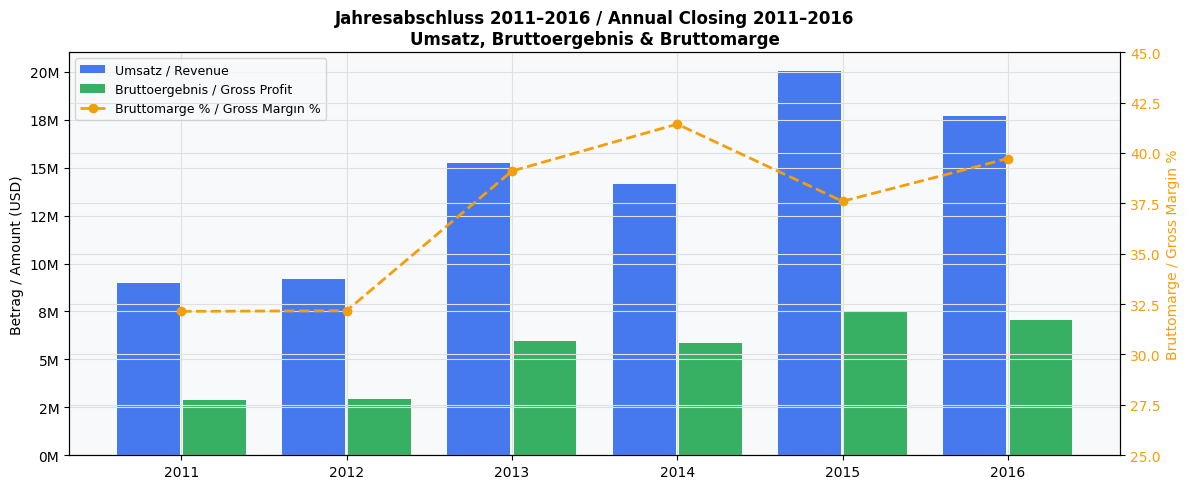

✓ Chart gespeichert / saved: chart_annual_closing.png


In [9]:
# ------------------------------------------------------------------
# DE: Jahresvergleichs-Chart / YoY comparison chart
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(annual))
ax.bar([i - 0.2 for i in x], annual['Umsatz'],   width=0.38,
       label='Umsatz / Revenue', color='#2563eb', alpha=0.85)
ax.bar([i + 0.2 for i in x], annual['Ergebnis'], width=0.38,
       label='Bruttoergebnis / Gross Profit', color='#16a34a', alpha=0.85)

ax2 = ax.twinx()
ax2.plot(list(x), annual['Bruttomarge_pct'], 'o--',
         color='#f59e0b', linewidth=2, markersize=6,
         label='Bruttomarge % / Gross Margin %')
ax2.set_ylabel('Bruttomarge / Gross Margin %', color='#f59e0b')
ax2.tick_params(axis='y', labelcolor='#f59e0b')
ax2.set_ylim(25, 45)

ax.set_xticks(list(x))
ax.set_xticklabels([str(y) for y in annual['fiscal_year']])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.0f}M'))
ax.set_ylabel('Betrag / Amount (USD)')
ax.set_title('Jahresabschluss 2011–2016 / Annual Closing 2011–2016\n'
             'Umsatz, Bruttoergebnis & Bruttomarge', fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/chart_annual_closing.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart gespeichert / saved: chart_annual_closing.png')

## 6. Abweichungskommentar / Variance Commentary <a id='6-abweichungskommentar'></a>

### 📖 Konzept / Concept

**DE:** Im echten Abschluss schreibt der Controller/Buchhalter für jede **wesentliche Abweichung** (≥ Materialitätsschwelle) einen strukturierten Kommentar:

```
Format eines Abweichungskommentars:
  [Periode]: [Umsatz X% über/unter Plan.] [Ursache/Erklärung.] [Maßnahme falls nötig.]
```

**Materialitätsschwelle (Materiality Threshold):** Ab welcher Abweichung wird kommentiert?
- Typisch im Handel: 3–5% des Plan-Umsatzes
- In dieser Simulation: 5%

**EN:** Material variances (≥ threshold) require a written explanation. This is a key audit and management requirement.


In [10]:
# ------------------------------------------------------------------
# DE: Automatische Abweichungskommentare generieren
#     In der Praxis: manuell vom Controller geschrieben
#     Hier: automatisch als Simulation
#
#     Materialitätsschwelle / Materiality threshold: 5%
#     → jede Abweichung ≥ 5% erhält einen Pflichtkommentar
# EN: Generate automatic variance commentary (simulation)
# ------------------------------------------------------------------

MATERIALITY_PCT = 5.0  # Materialitätsschwelle / Materiality threshold in %

def generate_comment_de(row):
    pct  = row['Umsatz_Abw_pct']
    per  = row['year_month_str']
    if abs(pct) < MATERIALITY_PCT:
        return f'{per}: Umsatz plankonform (Abw. {pct:+.1f}%). Kein Handlungsbedarf.'
    direction = 'über'  if pct > 0 else 'unter'
    reason    = 'Starke Nachfrage in Kategorie Bikes & Accessories.' if pct > 0 \
                else 'Saisonaler Rückgang; Kategorie Accessories schwächer als erwartet.'
    action    = '' if pct > 0 else ' CFO informiert.'
    return f'{per}: ⚠️ Umsatz {abs(pct):.1f}% {direction} Plan. {reason}{action}'

def generate_comment_en(row):
    pct  = row['Umsatz_Abw_pct']
    per  = row['year_month_str']
    if abs(pct) < MATERIALITY_PCT:
        return f'{per}: Revenue within plan (var. {pct:+.1f}%). No action required.'
    direction = 'above' if pct > 0 else 'below'
    reason    = 'Strong demand in Bikes & Accessories category.' if pct > 0 \
                else 'Seasonal decline; Accessories weaker than expected.'
    action    = '' if pct > 0 else ' CFO notified.'
    return f'{per}: ⚠️ Revenue {abs(pct):.1f}% {direction} plan. {reason}{action}'

monthly['Kommentar_DE'] = monthly.apply(generate_comment_de, axis=1)
monthly['Kommentar_EN'] = monthly.apply(generate_comment_en, axis=1)

# Ausgabe: nur wesentliche Abweichungen 2015
material = monthly[
    (monthly['fiscal_year'] == 2015) &
    (monthly['Umsatz_Abw_pct'].abs() >= MATERIALITY_PCT)
][['year_month_str','Umsatz_Abw_pct','Kommentar_DE','Kommentar_EN']]

print(f'Wesentliche Abweichungen 2015 (≥ {MATERIALITY_PCT}%) / Material variances 2015:')
print()
if len(material) == 0:
    print(f'  Keine wesentlichen Abweichungen / No material variances ≥ {MATERIALITY_PCT}%')
    print('  Alle Monate plankonform / All months within plan.')
else:
    for _, r in material.iterrows():
        print(f'  DE: {r["Kommentar_DE"]}')
        print(f'  EN: {r["Kommentar_EN"]}')
        print()
print(f'Monate ohne Kommentarpflicht / Months without required commentary: '
      f'{len(monthly[monthly["fiscal_year"]==2015]) - len(material)} von/of 12')

Wesentliche Abweichungen 2015 (≥ 5.0%) / Material variances 2015:

  Keine wesentlichen Abweichungen / No material variances ≥ 5.0%
  Alle Monate plankonform / All months within plan.
Monate ohne Kommentarpflicht / Months without required commentary: 12 von/of 12


## 7. Export nach Excel / Export to Excel <a id='7-export'></a>

**DE:** Alle Abschluss-Ergebnisse werden als CSV gespeichert und in der `closing_checklist.xlsx` (Modul 1 Excel) weiterverarbeitet.

**Exportierte Dateien:**
| Datei | Inhalt |
|-------|--------|
| `monthly_pl_final.csv` | Monatliche GuV inkl. ARAP/PRAP, Abweichungen, RAG, Kommentare |
| `annual_closing.csv` | Jahresabschluss 2011–2016 inkl. YoY-Kennzahlen |

**EN:** Results exported to CSV for further processing in Excel module (`closing_checklist.xlsx`).


In [11]:
# ------------------------------------------------------------------
# DE: Export – alle Ergebnisse als CSV für Excel-Modul
# EN: Export – all results as CSV for Excel module
# ------------------------------------------------------------------

monthly.to_csv('../data/processed/monthly_pl_final.csv', index=False, encoding='utf-8-sig')
annual.to_csv('../data/processed/annual_closing.csv',    index=False, encoding='utf-8-sig')

print('✓ Gespeichert / Saved:')
print('  → data/processed/monthly_pl_final.csv')
print(f'     Zeilen/Rows: {len(monthly)}  |  Spalten/Cols: {len(monthly.columns)}')
print()
print('  → data/processed/annual_closing.csv')
print(f'     Zeilen/Rows: {len(annual)}  |  Spalten/Cols: {len(annual.columns)}')
print()
print('─' * 55)
print('✅ Modul 1 abgeschlossen / Module 1 complete')
print()
print('Nächste Schritte / Next Steps:')
print('  1. Excel: closing_checklist.xlsx öffnen & Status aktualisieren')
print('  2. Python: 02_controlling_plan_ist.ipynb (Modul 2)')
print('─' * 55)

✓ Gespeichert / Saved:
  → data/processed/monthly_pl_final.csv
     Zeilen/Rows: 62  |  Spalten/Cols: 24

  → data/processed/annual_closing.csv
     Zeilen/Rows: 6  |  Spalten/Cols: 8

───────────────────────────────────────────────────────
✅ Modul 1 abgeschlossen / Module 1 complete

Nächste Schritte / Next Steps:
  1. Excel: closing_checklist.xlsx öffnen & Status aktualisieren
  2. Python: 02_controlling_plan_ist.ipynb (Modul 2)
───────────────────────────────────────────────────────
